# IntelliMaint

## Feature Engineering & Data Preparation

### Objective

The objective of this notebook is to transform the raw predictive maintenance
dataset into a machine-learning-ready dataset.

The process includes:

- Removing irrelevant identifiers
- Encoding categorical variables
- Creating domain-informed features
- Separating features and target
- Handling class imbalance
- Splitting data into training and testing sets
- Scaling numerical features where required

In [6]:
import sys
!{sys.executable} -m pip install scikit-learn imbalanced-learn

  Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached scikit_learn-1.9.0-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached narwhals-2.24.0-py3-none-any.whl (461 kB)
Using cached scipy-1.18.0-cp313-cp313-win_amd64.whl (36.6 MB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)



[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## Load Dataset

In [8]:
df = pd.read_csv("../dataset/ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
data = df.copy()

In [10]:
print(df.shape)

(10000, 14)


In [11]:
data["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [12]:
data["Machine failure"].value_counts(normalize=True) * 100

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64

In [13]:
data = data.drop(columns=["UDI", "Product ID"])

In [14]:
data.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [15]:
data = data.drop(
    columns=["TWF", "HDF", "PWF", "OSF", "RNF"]
)

In [16]:
X = data.drop(columns=["Machine failure"])
y = data["Machine failure"]

In [17]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


In [18]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

In [19]:
X["Temperature_Difference"] = (
    X["Process temperature [K]"] -
    X["Air temperature [K]"]
)

In [20]:
X["Mechanical_Power"] = (
    X["Torque [Nm]"] *
    X["Rotational speed [rpm]"] *
    2 * np.pi / 60
)

In [21]:
X["Thermal_Load_Index"] = (
    X["Temperature_Difference"] *
    X["Mechanical_Power"]
)

In [22]:
X["Torque_Speed_Interaction"] = (
    X["Torque [Nm]"] *
    X["Rotational speed [rpm]"]
)

In [23]:
X["Temperature_Ratio"] = (
    X["Process temperature [K]"] /
    X["Air temperature [K]"]
)

In [24]:
X["Wear_Load_Index"] = (
    X["Tool wear [min]"] *
    X["Torque [Nm]"]
)

In [25]:
X.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Temperature_Difference,Mechanical_Power,Thermal_Load_Index,Torque_Speed_Interaction,Temperature_Ratio,Wear_Load_Index
0,M,298.1,308.6,1551,42.8,0,10.5,6951.590560,72991.700882,66382.8,1.035223,0.0
1,L,298.2,308.7,1408,46.3,3,10.5,6826.722724,71680.588604,65190.4,1.035211,138.9
2,L,298.1,308.5,1498,49.4,5,10.4,7749.387543,80593.630443,74001.2,1.034888,247.0
3,L,298.2,308.6,1433,39.5,7,10.4,5927.504659,61646.048453,56603.5,1.034876,276.5
4,L,298.2,308.7,1408,40.0,9,10.5,5897.816608,61927.074388,56320.0,1.035211,360.0


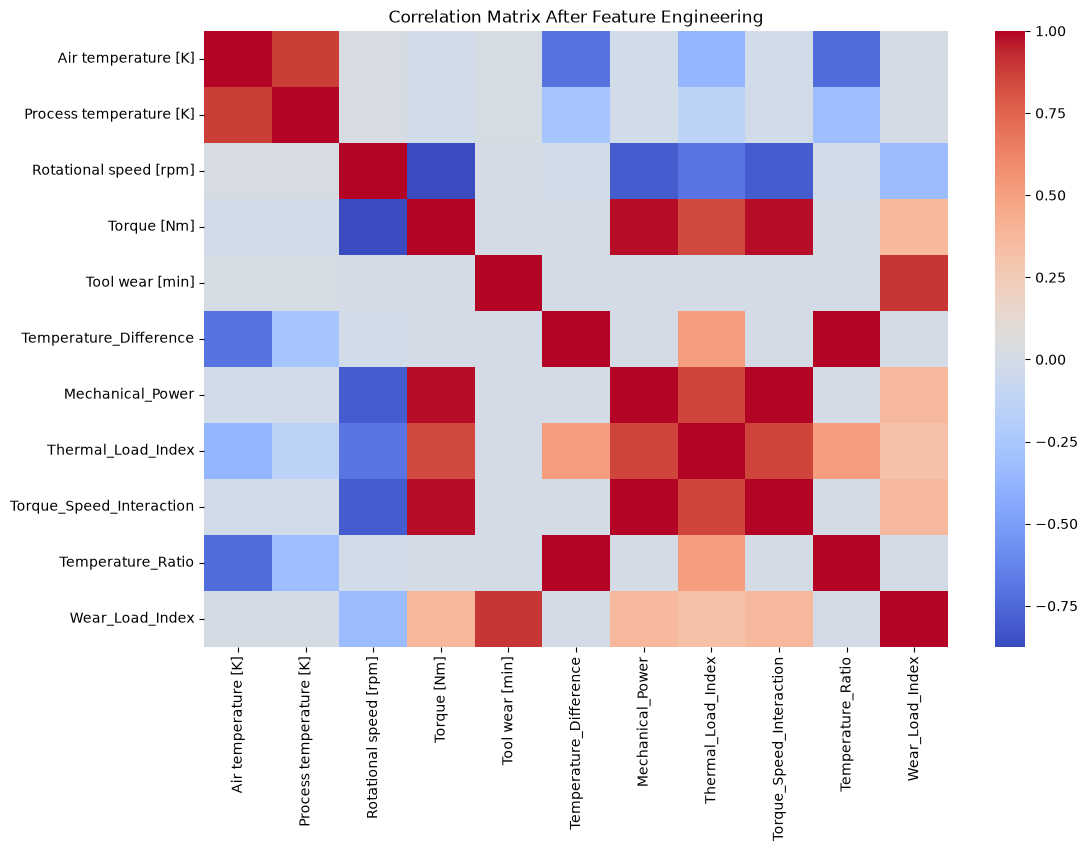

In [26]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    X.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

In [27]:
print("Missing values:")
print(X.isnull().sum().sum())

print("\nInfinite values:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Missing values:
0

Infinite values:
0


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [29]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training shape: (8000, 12)
Testing shape: (2000, 12)

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [30]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [31]:
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

In [32]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

Before SMOTE:
Machine failure
0    7729
1     271
Name: count, dtype: int64

After SMOTE:
Machine failure
0    7729
1    7729
Name: count, dtype: int64


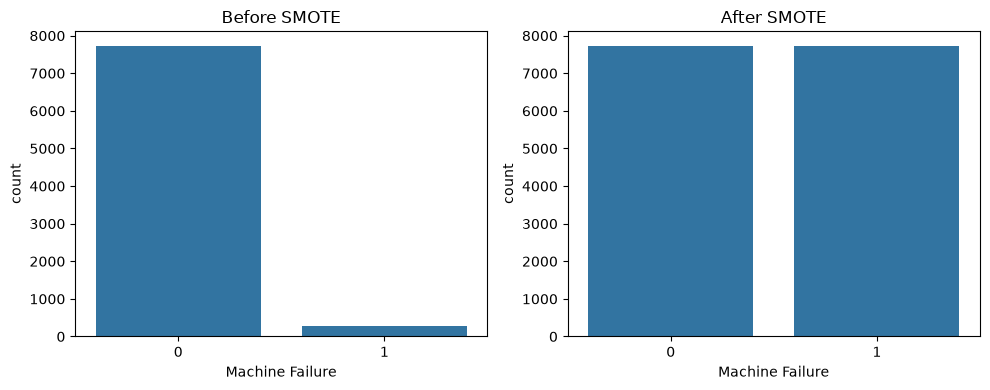

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(
    x=y_train,
    ax=axes[0]
)

axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Machine Failure")

sns.countplot(
    x=y_train_resampled,
    ax=axes[1]
)

axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Machine Failure")

plt.tight_layout()
plt.show()

In [34]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_resampled)

X_test_scaled = scaler.transform(X_test)

In [35]:
final_data = X.copy()

final_data["Machine failure"] = y

final_data.to_csv(
    "../dataset/intellimaint_engineered.csv",
    index=False
)

In [36]:
print("Final feature count:", X.shape[1])

print("\nTraining samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nFinal features:")
print(X.columns.tolist())

Final feature count: 12

Training samples: 8000
Testing samples: 2000

Final features:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature_Difference', 'Mechanical_Power', 'Thermal_Load_Index', 'Torque_Speed_Interaction', 'Temperature_Ratio', 'Wear_Load_Index']


02_FeatureEngineering.ipynb

# IntelliMaint

## Feature Engineering & Data Preparation

        ↓

## Objective

        ↓

## Import Libraries

        ↓

## Load Dataset

        ↓

## Create Working Copy

        ↓

## Target Analysis

        ↓

## Remove Identifier Columns

        ↓

## Prevent Target Leakage

        ↓

## Separate X and y

        ↓

## Encode Categorical Features

        ↓

## Domain-Informed Feature Engineering

        ↓

Temperature Difference

Mechanical Power

Thermal Load Index

Torque-Speed Interaction

Temperature Ratio

Wear-Load Index

        ↓

## Feature Validation

        ↓

## Train-Test Split

        ↓

## Handle Class Imbalance

SMOTE

        ↓

## Feature Scaling

        ↓

## Save Engineered Dataset

        ↓

## Final Validation

        ↓

# Conclusion

# Conclusion

The raw predictive maintenance dataset was transformed into a machine-learning-ready representation.

Irrelevant identifier columns were removed, categorical machine types were encoded, and failure-related columns that could cause target leakage were excluded from the predictive feature set.

Domain-informed features including temperature difference, mechanical power, thermal load, torque-speed interaction, temperature ratio, and wear-load interaction were engineered to represent potentially meaningful physical relationships.

The dataset was then divided into stratified training and testing sets. SMOTE was applied exclusively to the training data to address class imbalance, while feature scaling was prepared for algorithms that require normalized numerical inputs.

The resulting dataset provides a robust foundation for comparative machine learning model development in the next phase of IntelliMaint.